In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from scipy.optimize import minimize

In [105]:
rodar_nm = True
resetar_banco = True

In [106]:
import os
import glob

# Sua variável de controle

# Caminho da pasta que será limpa
caminho_pasta = r'.\tests_nm\results'

if resetar_banco:
    # Cria uma lista com todos os itens (*) dentro da pasta
    arquivos = glob.glob(os.path.join(caminho_pasta, '*'))
    
    if not arquivos:
        print("A pasta já está vazia.")
    else:
        for arquivo in arquivos:
            try:
                # Garante que vai apagar apenas arquivos, ignorando subpastas caso existam
                if os.path.isfile(arquivo):
                    os.remove(arquivo)
                    print(f"Arquivo apagado: {arquivo}")
            except Exception as e:
                print(f"Erro ao tentar apagar {arquivo}: {e}")
                
        print(f"Limpeza da pasta {caminho_pasta} concluída com sucesso!")

Arquivo apagado: .\tests_nm\results\nm_occ0.2.csv
Arquivo apagado: .\tests_nm\results\nm_occ0.5.csv
Arquivo apagado: .\tests_nm\results\nm_occ0.7.csv
Arquivo apagado: .\tests_nm\results\nm_occ0.9.csv
Limpeza da pasta .\tests_nm\results concluída com sucesso!


In [ ]:
data = [pd.read_csv(r'database\data_occ0_2.csv'),
        pd.read_csv(r'database\data_occ0_5.csv'),
        pd.read_csv(r'database\data_occ0_7.csv'),
        pd.read_csv(r'database\data_occ0_9.csv'),]

phase = [pd.read_csv(r'database\original-database\occupancy_0.2.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.5.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.7.CSV', index_col = False)['phases'][3:69997],
          pd.read_csv(r'database\original-database\occupancy_0.9.CSV', index_col = False)['phases'][3:69997]]

for i in range(4):
    data[i]['phases'] = phase[i].values

phases = [-5,-4, -3, -2, -1, 0, 1, 2, 3, 4, 5]
phasecut1 = [-5,-4, -3, -2, -1, 0, 1]
phasecut2 = [-1, 0, 1, 2, 3, 4, 5]
columns = data[0].columns
occ_name = ['occ0.2', 'occ0.5', 'occ0.7', 'occ0.9']

In [108]:
def subtrai_estimada(sinalrecebido, resultado_neldermead):
    A = resultado_neldermead
    sample = sinalrecebido

    #Subtrai cada amplitude estimada do sinal recebido, considerando o padrão do sinal e ignorando a quarta amostra
    signalPattern = np.array([
            [A[0]*1.0    , A[1]*0.4524   , A[2]*0.0172   , 0             , 0             , 0             , 0],
            [A[0]*0.5633 , A[1]*1        , A[2]*0.4524   , A[3]*0.0172   , 0             , 0             , 0],
            [A[0]*0.1493 , A[1]*0.5633   , A[2]*1        , A[3]*0.4524   , A[4]*0.0172   , 0             , 0],
            [0           , 0             , 0             , 0             , 0             , 0             , 0],
            [0           , A[1]*0.0424   , A[2]*0.1493   , A[3]*0.5633   , A[4]*1        , A[5]*0.4524   , A[6]*0.0172],
            [0           , 0             , A[2]*0.0424   , A[3]*0.1493   , A[4]*0.5633   , A[5]*1        , A[6]*0.4524],
            [0           , 0             , 0             , A[3]*0.0424   , A[4]*0.1493   , A[5]*0.5633   , A[6]*1]
            ])
    
    for i in range(len(sinalrecebido)):
        sample = sample - signalPattern[i]
        #print(sample)
    
    return sample


In [109]:
def nelder_mead(df, tol):
    def cost_function7(A):
        signalPattern = np.array([
            A[0]*1.0    + A[1]*0.4524   + A[2]*0.0172   + 0             + 0             + 0             + 0,
            A[0]*0.5633 + A[1]*1        + A[2]*0.4524   + A[3]*0.0172   + 0             + 0             + 0,
            A[0]*0.1493 + A[1]*0.5633   + A[2]*1        + A[3]*0.4524   + A[4]*0.0172   + 0             + 0,
            A[0]*0.0424 + A[1]*0.1493   + A[2]*0.5633   + A[3]*1        + A[4]*0.4524   + A[5]*0.0172   + 0,
            0           + A[1]*0.0424   + A[2]*0.1493   + A[3]*0.5633   + A[4]*1        + A[5]*0.4524   + A[6]*0.0172,
            0           + 0             + A[2]*0.0424   + A[3]*0.1493   + A[4]*0.5633   + A[5]*1        + A[6]*0.4524,
            0           + 0             + 0             + A[3]*0.0424   + A[4]*0.1493   + A[5]*0.5633   + A[6]*1
            ])
        aux_sum = samples - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(samples))**0.5

    def cost_function11pt1(A): #Primeira parte da matriz 11x11, linhas 1 a 7
        signalPattern = np.array([
    A[0] *1.0000 + A[1] *0.9989 + A[2] *0.9957 + A[3] *0.9902 + A[4] *0.9825 + A[5] *0.9725 + A[6] *0.9604 + A[7] *0.9462 + A[8] *0.9299 + A[9] *0.9116 + A[10]*0.8913,
    A[0] *0.9989 + A[1] *1.0000 + A[2] *0.9989 + A[3] *0.9957 + A[4] *0.9902 + A[5] *0.9825 + A[6] *0.9725 + A[7] *0.9604 + A[8] *0.9462 + A[9] *0.9299 + A[10]*0.9116,
    A[0] *0.9958 + A[1] *0.9989 + A[2] *1.0000 + A[3] *0.9989 + A[4] *0.9957 + A[5] *0.9902 + A[6] *0.9825 + A[7] *0.9725 + A[8] *0.9604 + A[9] *0.9462 + A[10]*0.9299,
    A[0] *0.9906 + A[1] *0.9958 + A[2] *0.9989 + A[3] *1.0000 + A[4] *0.9989 + A[5] *0.9957 + A[6] *0.9902 + A[7] *0.9825 + A[8] *0.9725 + A[9] *0.9604 + A[10]*0.9462,
    A[0] *0.9835 + A[1] *0.9906 + A[2] *0.9958 + A[3] *0.9989 + A[4] *1.0000 + A[5] *0.9989 + A[6] *0.9957 + A[7] *0.9902 + A[8] *0.9825 + A[9] *0.9725 + A[10]*0.9604,
    A[0] *0.9744 + A[1] *0.9835 + A[2] *0.9906 + A[3] *0.9958 + A[4] *0.9989 + A[5] *1.0000 + A[6] *0.9989 + A[7] *0.9957 + A[8] *0.9902 + A[9] *0.9825 + A[10]*0.9725,
    A[0] *0.9634 + A[1] *0.9744 + A[2] *0.9835 + A[3] *0.9906 + A[4] *0.9958 + A[5] *0.9989 + A[6] *1.0000 + A[7] *0.9989 + A[8] *0.9957 + A[9] *0.9902 + A[10]*0.9825,
    ])
        aux_sum = subtraida - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(subtraida))**0.5
    
    def cost_function11pt2(A): #Segunda parte da matriz 11x11, linhas 5 a 11
        signalPattern = np.array([
    A[0] *0.9835 + A[1] *0.9906 + A[2] *0.9958 + A[3] *0.9989 + A[4] *1.0000 + A[5] *0.9989 + A[6] *0.9957 + A[7] *0.9902 + A[8] *0.9825 + A[9] *0.9725 + A[10]*0.9604,
    A[0] *0.9744 + A[1] *0.9835 + A[2] *0.9906 + A[3] *0.9958 + A[4] *0.9989 + A[5] *1.0000 + A[6] *0.9989 + A[7] *0.9957 + A[8] *0.9902 + A[9] *0.9825 + A[10]*0.9725,
    A[0] *0.9634 + A[1] *0.9744 + A[2] *0.9835 + A[3] *0.9906 + A[4] *0.9958 + A[5] *0.9989 + A[6] *1.0000 + A[7] *0.9989 + A[8] *0.9957 + A[9] *0.9902 + A[10]*0.9825,
    A[0] *0.9507 + A[1] *0.9634 + A[2] *0.9744 + A[3] *0.9835 + A[4] *0.9906 + A[5] *0.9958 + A[6] *0.9989 + A[7] *1.0000 + A[8] *0.9989 + A[9] *0.9957 + A[10]*0.9902,
    A[0] *0.9364 + A[1] *0.9507 + A[2] *0.9634 + A[3] *0.9744 + A[4] *0.9835 + A[5] *0.9906 + A[6] *0.9958 + A[7] *0.9989 + A[8] *1.0000 + A[9] *0.9989 + A[10]*0.9957,
    A[0] *0.9206 + A[1] *0.9364 + A[2] *0.9507 + A[3] *0.9634 + A[4] *0.9744 + A[5] *0.9835 + A[6] *0.9906 + A[7] *0.9958 + A[8] *0.9989 + A[9] *1.0000 + A[10]*0.9989,
    A[0] *0.9035 + A[1] *0.9206 + A[2] *0.9364 + A[3] *0.9507 + A[4] *0.9634 + A[5] *0.9744 + A[6] *0.9835 + A[7] *0.9906 + A[8] *0.9958 + A[9] *0.9989 + A[10]*1.0000,
    ])
        aux_sum = subtraida - signalPattern # "samples" are declared in each iteration of the for loop
        return (sum(aux_sum**2) / len(subtraida))**0.5

    def parada7(xk):
        erro_atual = cost_function7(xk)
        if erro_atual < tol:
            raise StopIteration  
    
    def parada11pt1(xk):
        erro_atual = cost_function11pt1(xk)
        if erro_atual < tol:
            raise StopIteration 

    def parada11pt2(xk):
        erro_atual = cost_function11pt2(xk)
        if erro_atual < tol:
            raise StopIteration
        
    sample4 = [] #Valor da amplitude do quarto sample para a solução encontrada
    iter_list = [] #Quatidade de iterações para a solução encontrada
    fun_list = [] #Valor da função objetivo para a solução encontrada
    ns_list = [] #Lista de ns para cada sample

    for samples in df:

        res = minimize(cost_function7, samples, method='Nelder-Mead', callback=parada7, options={'maxiter': 700, 'xatol': 1e-100, 'fatol': 1e-100, 'disp': False, 'adaptive': True})
        subtraida = subtrai_estimada(samples, res.x)
        sample4.append(res.x[3])
        #iter_list.append(res.nit)
        fun_list.append(res.fun)
        
        chute_inicial_11 = np.ones(11) #como a próxima estimação possui 11 parametros no A, é criado um de chute formado por 0 com 11 parametros  
        res1 = minimize(cost_function11pt1, chute_inicial_11, method='Nelder-Mead', callback=parada11pt1, options={'maxiter': 300, 'xatol': 1e-100, 'fatol': 1e-100, 'disp': False, 'adaptive': True})
        res2 = minimize(cost_function11pt2, chute_inicial_11, method='Nelder-Mead', callback=parada11pt2, options={'maxiter': 300, 'xatol': 1e-100, 'fatol': 1e-100, 'disp': False, 'adaptive': True})
        #ns_list.append(phases[np.argmax(res.x)]) #salva o valor da phase

        if phases[np.argmax(res1.x)] == phases[np.argmax(res2.x)]:
            ns_list.append(phases[np.argmax(res1.x)]) #salva o valor da phase se forem iguais
        
        elif phases[np.argmax(res1.x)] == phasecut1[-1] and phases[np.argmax(res2.x)] > phasecut1[-1]:
            ns_list.append(phases[np.argmax(res2.x)]) #salva o valor da phase se ele for igual ao ultimo valor do phasecut1 e o outro for maior que ele
        else:
            ns_list.append(phases[np.argmax(res1.x)]) #salva o valor da phase
        

    return sample4, fun_list, ns_list

In [110]:
def save_nm(sample4, tol, occ, phase, fun_list, ns_list, amplitude):
    path = f'.\\tests_nm\\results\\nm_{occ}.csv'

    if os.path.exists(path):
        df = pd.read_csv(path)
        new_df = pd.DataFrame({                    
            'TrueAmplitude': amplitude,
            'EstimatedAmplitude': sample4,
            'TruePhase': phase,
            'PhaseEstimada': ns_list,
            'tolerance': tol,
            'function_values': fun_list,})
        
        df = pd.concat([df, new_df], ignore_index=True)
    else:
        df = pd.DataFrame({
            'TrueAmplitude': amplitude,
            'EstimatedAmplitude': sample4,
            'TruePhase': phase,
            'PhaseEstimada': ns_list,
            'tolerance': tol,
            'function_values': fun_list,
        })

    df.to_csv(f'.\\tests_nm\\results\\nm_{occ}.csv', index=False)

In [111]:
def run_algorithm(data):

    #reset_save() #Limpa os arquivos de resultados antes de rodar o algoritmo
    #Para cada ocupação e cada tolerância, roda o método de Nelder-Mead e salva os resultados
    if rodar_nm:
        k = 0
        for i in range(4):
            samples_data = np.array(data[i][columns[0:7]])
            amplitudes_data = np.array(data[i][columns[7]])
            phases_data = np.array(data[i][columns[8]])

            sample4, fun_list, ns_list = nelder_mead(samples_data, tol=1)
            save_nm(sample4, 1, occ_name[i], phases_data, fun_list, ns_list, amplitudes_data)
            k +=1
            print(f'Occupancy {occ_name[i][3:]} and tolerance {1} done, lacking {4 - k} combinations')

In [112]:
run_algorithm(data)

Occupancy 0.2 and tolerance 1 done, lacking 3 combinations
Occupancy 0.5 and tolerance 1 done, lacking 2 combinations
Occupancy 0.7 and tolerance 1 done, lacking 1 combinations
Occupancy 0.9 and tolerance 1 done, lacking 0 combinations


In [113]:
def load_results():
    resultados = [
        pd.read_csv(r'.\tests_nm\results\nm_occ0.2.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.5.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.7.csv'),
        pd.read_csv(r'.\tests_nm\results\nm_occ0.9.csv'),
    ]
    return resultados

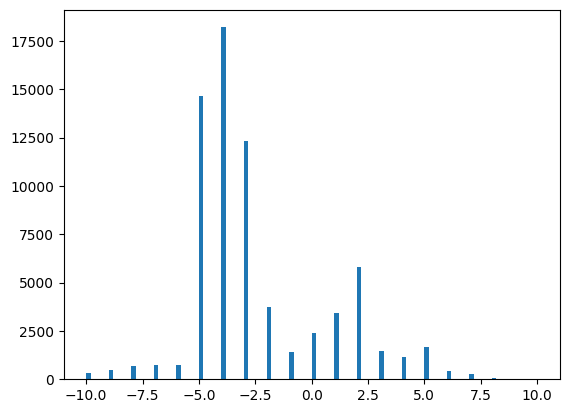

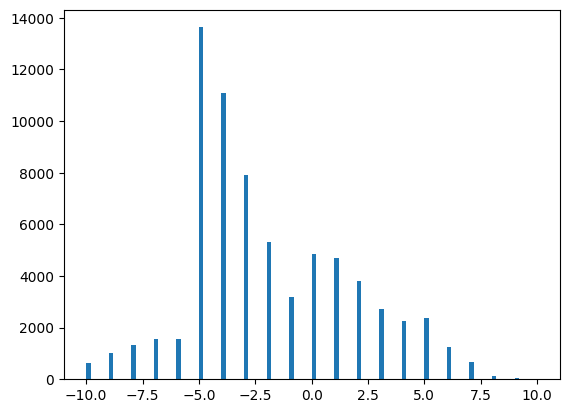

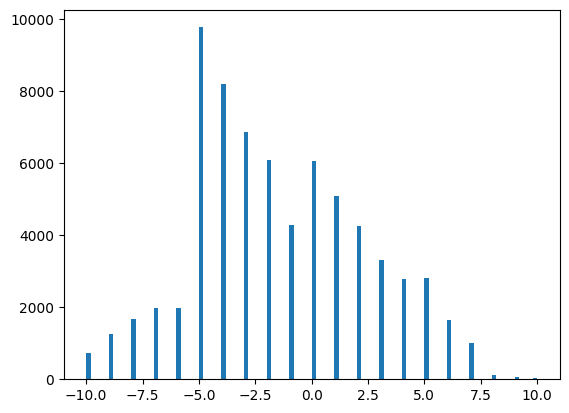

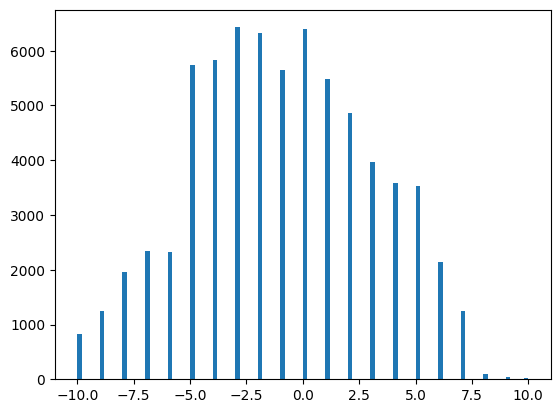

In [114]:
df = load_results()

for i in range(len(df)):
    phase_error = df[i]['TruePhase'] - df[i]['PhaseEstimada']
    plt.hist(phase_error, bins=100)
    plt.show()

In [115]:
def linearfit(real, estimada, name, occ):
    a, b = np.polyfit(real, estimada, 1)
    x_fit = np.linspace(real.min(), real.max(), 100)
    y_fit = a*x_fit + b
    plt.scatter(real, estimada, alpha=0.2, s=15, label='Predições')

# ideal        
    plt.plot(x_fit, x_fit, '--', color='black', linewidth=3, label='Ideal')

# fit
    plt.plot(x_fit, y_fit, '-', color='red', linewidth=3, label=f'Fit: y={a:.2f}x + {b:.2f}')

    plt.xlabel('Phase Real')
    plt.ylabel('Phase Predita')
    plt.title(f'{name} Real vs Predito - {occ}')
    plt.legend()
    plt.grid(True)
    plt.show()

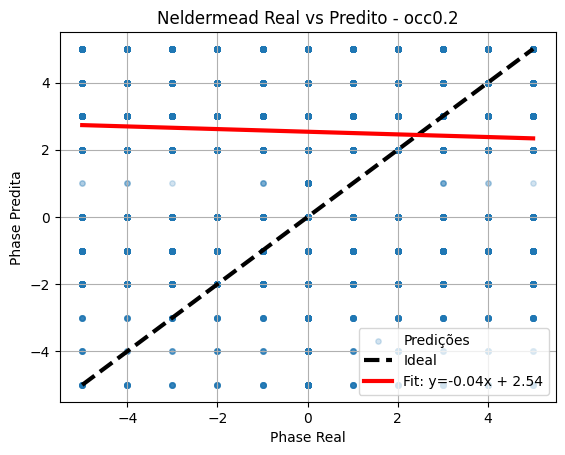

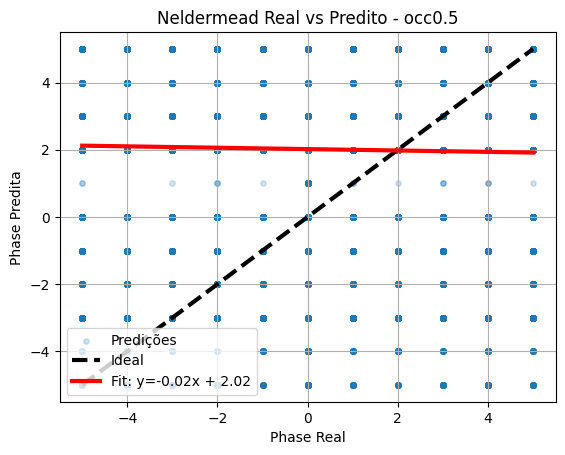

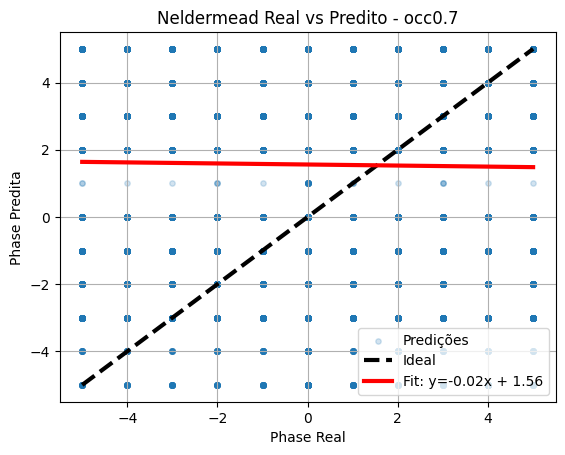

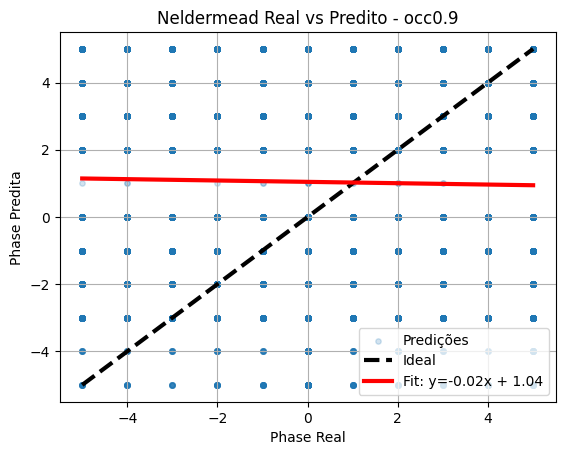

In [116]:
df = load_results()

for i in range(len(df)):
    linearfit(df[i]['TruePhase'], df[i]['PhaseEstimada'], 'Neldermead', occ_name[i])